# Word Embeddings & Seq2Seq (Word2Vec, GloVe, FastText)

This notebook has **three parts**:

1. **Word Embeddings**
   - Train simple versions of **Word2Vec**, **GloVe**, and a **FastText-like** model on a tiny corpus.
   - Visualize and compare their 2D manifolds (visualization is fully provided).

2. **Seq2Seq with Embeddings**
   - Build a small **encoder–decoder (seq2seq)** model.
   - Task: given a sentence, predict the **same sentence in reverse word order**.
   - Use the embeddings learned in Part 1 as input representations.

3. **Big Seq 2 Seq Encoder Decoder**
   - Load big corpus and use different embeddings
   - Ajust Encoder and Decoder
   - Train on the same task as 2. 
   - Compare the results and generalisation


In [35]:
!pip install -q torch torchvision torchaudio scikit-learn matplotlib

In [36]:
import math
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import TensorDataset, DataLoader
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)


Using device: cpu


## Part 1 – Word Embeddings (Word2Vec, GloVe, FastText-like)


## 1. Corpus, tokenization and vocabulary

We will use a tiny corpus about cats, dogs and mouses.

**Tasks**

1. Flatten all tokens into a list.
2. Build `vocab` (sorted list).
3. Build `stoi` (string→index) and `itos` (index→string).
4. Convert each sentence to a list of indices (`indexed_corpus`).


In [37]:
corpus = [
    "the cat sat on the mat",
    "the dog lay on the rug",
    "dogs and cats are friends",
    "the cat chased the mouse",
    "the dog chased the cat",
    "cats and dogs can be friends",
    "dogs are friends",
    "the dog sat on the mat"
]

tokens = []     
for sentence in corpus:
    tokens.extend(sentence.split())
vocab = {word: i for i, word in enumerate(sorted(set(tokens)))}
stoi = vocab
vocab = sorted(vocab.keys())
itos = {i: word for word, i in stoi.items()}
vocab_size = len(vocab)

print("Vocab:", vocab)
print("Vocab size:", vocab_size)

# TODO: 4) indexed_corpus: list of lists of indices
indexed_corpus = [[stoi[word] for word in sentence.split()] for sentence in corpus]
print("indexed_corpus", indexed_corpus)


Vocab: ['and', 'are', 'be', 'can', 'cat', 'cats', 'chased', 'dog', 'dogs', 'friends', 'lay', 'mat', 'mouse', 'on', 'rug', 'sat', 'the']
Vocab size: 17
indexed_corpus [[16, 4, 15, 13, 16, 11], [16, 7, 10, 13, 16, 14], [8, 0, 5, 1, 9], [16, 4, 6, 16, 12], [16, 7, 6, 16, 4], [5, 0, 8, 3, 2, 9], [8, 1, 9], [16, 7, 15, 13, 16, 11]]


## 2. Skip-gram training pairs

Create `(center, context)` pairs using a symmetric window.

**Pseudocode**

```text
for each sentence s:
    for each index i:
        center = s[i]
        for j in [i-window, ..., i+window], j != i:
            if j inside sentence:
                context = s[j]
                add (center, context)


In [38]:
def build_skipgram_pairs(indexed_sents, window_size=2):
    pairs = []
    for sent in indexed_sents:
        for i in range(len(sent)):
            center = sent[i]
            for j in range(max(0, i - window_size), min(len(sent), i + window_size + 1)):
                if j != i and j >= 0 and j < len(sent):
                    context = sent[j]
                    pairs.append((center, context))
    return pairs

pairs = build_skipgram_pairs(indexed_corpus, window_size=2)
print("Num skip-gram pairs:", len(pairs))
print("First 10 pairs:", pairs[:10])

centers = torch.tensor([p[0] for p in pairs], dtype=torch.long)
contexts = torch.tensor([p[1] for p in pairs], dtype=torch.long)
centers.shape, contexts.shape

Num skip-gram pairs: 120
First 10 pairs: [(16, 4), (16, 15), (4, 16), (4, 15), (4, 13), (15, 16), (15, 4), (15, 13), (15, 16), (13, 4)]


(torch.Size([120]), torch.Size([120]))

## 3. Word2Vec – Skip-gram with Softmax

We learn an embedding such that the **center word** predicts its **context words**.

$$
P(w_o \mid w_c) = \frac{\exp(v_{w_o}^\top v_{w_c})}{\sum_{w=1}^{|V|} \exp(v_w^\top v_{w_c})}
$$

Where:

- $ w_c $: center word
- $ w_o $: context word
- $ v_{w_c} $: embedding vector of the center word
- $ v_{w_o} $: embedding vector of the context word

We maximize the probability of the **true** context word and implicitly push down all others.

---

### Model structure (`SkipGramSoftmax`)

The model has two main parts:

1. **Input embedding**:  
   `self.in_emb = nn.Embedding(vocab_size, emb_dim)`  
   This maps a **center word index** (e.g. 5) to a dense vector $ v_{w_c} \in \mathbb{R}^{emb\_dim} $.

2. **Output layer**:  
   `self.out = nn.Linear(emb_dim, vocab_size, bias=False)`  
   This maps the embedding vector to **logits over the whole vocabulary**.  
   - Input shape: `(batch_size, emb_dim)`  
   - Output shape: `(batch_size, vocab_size)`  

So in `forward`:

1. Look up embeddings for center words:  
   `v = self.in_emb(center_words)` → shape `(B, emb_dim)`
2. Project to vocabulary logits:  
   `logits = self.out(v)` → shape `(B, vocab_size)`

---
We already have all (center, context) pairs in two tensors:

- `centers`: Tensor of shape `(N,)` with center word indices  
- `contexts`: Tensor of shape `(N,)` with **target** context word indices

We want to train the model so that:

- Given `centers` as input,
- It predicts `contexts` with high probability.

We do this with `CrossEntropyLoss`, which combines **log-softmax + NLL** for us.



In [39]:
class SkipGramSoftmax(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.in_emb = nn.Embedding(vocab_size, emb_dim)
        self.out = nn.Linear(emb_dim, vocab_size) #vai dar uma distribuição de probabilidades para cada palavra do vocabulário

    def forward(self, center_words):
        v = self.in_emb(center_words)  # (B, emb_dim)
        logits = self.out(v)   # (B, vocab_size)
        return logits


def train_word2vec(centers, contexts, vocab_size, emb_dim=50, epochs=200, batch_size=32, lr=0.01): #emb_dim é o tamanho do embedding, neste caso é maior que a dimensão original do problema (17)
    dataset = TensorDataset(centers, contexts)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = SkipGramSoftmax(vocab_size, emb_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0.0
        for c_batch, ctx_batch in loader:
            c_batch = c_batch.to(device)  #centers 
            ctx_batch = ctx_batch.to(device) #contexts 

            logits = model(c_batch)                        # TODO: forward
            loss = criterion(logits, ctx_batch)            # TODO: CE loss

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(c_batch)

        if (epoch + 1) % 50 == 0:
            print(f"[W2V] Epoch {epoch+1}/{epochs} - loss: {total_loss / len(dataset):.4f}")
    return model

w2v_model = train_word2vec(centers, contexts, vocab_size)
w2v_embeddings = w2v_model.in_emb.weight.detach().cpu()
w2v_embeddings.shape


[W2V] Epoch 50/200 - loss: 1.5445
[W2V] Epoch 100/200 - loss: 1.5406
[W2V] Epoch 150/200 - loss: 1.5375
[W2V] Epoch 200/200 - loss: 1.5406


torch.Size([17, 50])

## 4. GloVe – Global Vectors


GloVe (Global Vectors) learns word embeddings by looking at **global co-occurrence statistics** instead of predicting local context words one by one (like Word2Vec). The main idea is:

1. Build a **co-occurrence matrix** $X_{ij}$, where $X_{ij}$ counts how often word $j$ appears in the context of word $i$ (within a window).
2. Learn word vectors $v_i$ and $v_j$ such that their dot product plus biases approximates $\log X_{ij}$.

The objective function (for all word pairs $(i, j)$ with non-zero co-occurrence) is:

$$
J = \sum_{i,j} f(X_{ij}) \big( v_i^\top \tilde{v}_j + b_i + \tilde{b}_j - \log X_{ij} \big)^2
$$

where:
- $v_i$ = "target" embedding for word $i$  
- $\tilde{v}_j$ = "context" embedding for word $j$  
- $b_i, \tilde{b}_j$ = scalar biases  
- $f(X_{ij})$ = weighting function that downweights very rare and very frequent pairs.

---

### What you need to implement

There are **three key pieces** in the code:

1. **`build_cooccurrences`**  
   - Input: `indexed_sents`, `window_size`  
   - Output: a dictionary `cooc[(i, j)] = X_ij` with co-occurrence counts.
   - For each sentence and each position, look at neighbors within `window_size` and increment `cooc[(center, context)]`.  
   - Often, counts are **weighted by inverse distance** (e.g. `1 / distance`) so closer words contribute more.

2. **`GloveModel.forward`**  
   - You already have embeddings and biases:
     - `self.wi` (target embeddings)
     - `self.wj` (context embeddings)
     - `self.bi`, `self.bj` (biases)
   - Given `i_idx` and `j_idx` (tensors of word indices), you should:
     - Look up `wi = self.wi(i_idx)` and `wj = self.wj(j_idx)`  
     - Look up `bi = self.bi(i_idx)` and `bj = self.bj(j_idx)`  
     - Compute the scalar score:
       \[
       \text{score} = v_i^\top v_j + b_i + b_j
       \]
     - So the forward should return a 1D tensor of predictions of shape `(num_pairs,)`, each approximating $\log X_{ij}\).

3. **`train_glove` loss computation**  
   - You are given:
     - `x_ij` (co-occurrence counts for each pair)
     - `log_xij = log(x_ij)`
     - `weights = f(x_ij)` from `glove_weight`
   - For each pair, you want to compute:
     \[
     f(X_{ij}) \left( \text{pred}_{ij} - \log X_{ij} \right)^2
     \]
   - In code:
     - Call the model to get scores.  
     - Compute squared error `(preds - log_xij) ** 2`.  
     - Multiply by weights for the loss: `(weights * se).mean()` (or `.sum() / N`).

At the end of training, we usually **combine** the two sets of embeddings (target and context) by averaging them:


In [40]:
def build_cooccurrences(indexed_sents, window_size=2):
    cooc = defaultdict(float)
    for sent in indexed_sents:
        for i in range(len(sent)):
            center = sent[i]
            for j in range(max(0, i - window_size), min(len(sent), i + window_size + 1)):
                if j != i and j >= 0 and j < len(sent):
                    distance = abs(i - j)
                    increment = 1.0 / distance
                    cooc[(center, sent[j])] += increment
    
    return cooc



cooc = build_cooccurrences(indexed_corpus, window_size=2)
print("Num non-zero co-occurrences:", len(cooc))

i_ids, j_ids, x_ij_list = [], [], []
for (i, j), x in cooc.items():
    i_ids.append(i)
    j_ids.append(j)
    x_ij_list.append(x)

i_ids = torch.tensor(i_ids, dtype=torch.long)
j_ids = torch.tensor(j_ids, dtype=torch.long)
x_ij = torch.tensor(x_ij_list, dtype=torch.float)


Num non-zero co-occurrences: 72


In [41]:
class GloveModel(nn.Module):
    def __init__(self, vocab_size, emb_dim):
        super().__init__()
        self.wi = nn.Embedding(vocab_size, emb_dim)
        self.wj = nn.Embedding(vocab_size, emb_dim)
        self.bi = nn.Embedding(vocab_size, 1)
        self.bj = nn.Embedding(vocab_size, 1)

    def forward(self, i_idx, j_idx):
        wi = self.wi(i_idx)  # (N, emb_dim)
        wj = self.wj(j_idx)  # (N, emb_dim)
        bi = self.bi(i_idx)  # (N, 1)
        bj = self.bj(j_idx)  # (N, 1)
        return  ((wi * wj).sum(dim=1) + bi + bj)  # v_i^T v_j + b_i + b_j


def glove_weight(x, x_max=100.0, alpha=0.75):
    return torch.where(x < x_max, (x / x_max) ** alpha, torch.ones_like(x))


def train_glove(i_ids, j_ids, x_ij, vocab_size, emb_dim=50, epochs=200, lr=0.05):
    model = GloveModel(vocab_size, emb_dim).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    weights = glove_weight(x_ij).to(device)
    log_xij = torch.log(x_ij).to(device)
    i_ids_d = i_ids.to(device)
    j_ids_d = j_ids.to(device)

    for epoch in range(epochs):
        preds = model(i_ids_d, j_ids_d)  # TODO: forward
        MSE = (preds - log_xij) ** 2
        print(log_xij)
        loss = (weights * (MSE)).mean()  # TODO: weighted MSE
        print(loss)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (epoch + 1) % 50 == 0:
            print(f"[GloVe] Epoch {epoch+1}/{epochs} - loss: {loss.item():.4f}")
    return model

glove_model = train_glove(i_ids, j_ids, x_ij, vocab_size)
glove_embeddings = (glove_model.wi.weight.detach().cpu() + 
                    glove_model.wj.weight.detach().cpu()) / 2.0
glove_embeddings.shape


tensor([ 1.2528,  0.6931,  1.2528,  0.0000, -0.6931,  0.6931,  0.0000,  0.6931,
        -0.6931,  0.6931,  1.0986,  0.0000,  1.0986,  0.6931,  0.0000,  0.6931,
         1.2528,  0.0000,  1.2528,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,
         0.0000,  0.0000, -0.6931,  0.0000, -0.6931,  0.0000,  0.6931,  0.0000,
         0.6931,  0.6931, -0.6931,  0.0000,  0.6931,  0.0000, -0.6931, -0.6931,
         0.0000,  0.6931, -0.6931,  0.6931,  1.0986,  0.4055,  1.0986,  0.4055,
        -0.6931,  0.0000, -0.6931,  0.0000,  0.0000,  0.0000, -0.6931,  0.0000,
        -0.6931, -0.6931,  0.0000,  0.0000, -0.6931, -0.6931,  0.0000,  0.0000,
        -0.6931,  0.0000,  0.0000, -0.6931,  0.0000, -0.6931,  0.0000,  0.0000])
tensor(1.9156, grad_fn=<MeanBackward0>)
tensor([ 1.2528,  0.6931,  1.2528,  0.0000, -0.6931,  0.6931,  0.0000,  0.6931,
        -0.6931,  0.6931,  1.0986,  0.0000,  1.0986,  0.6931,  0.0000,  0.6931,
         1.2528,  0.0000,  1.2528,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,

torch.Size([17, 50])

## 5. FastText-like – Character n-grams

FastText extends Word2Vec by representing each word not just as a single vector, but as the **sum or average of its character n-gram vectors**. This helps with:

- **Rare words**: they share subword units with more frequent words.
- **Morphology**: prefixes/suffixes (e.g. "un-", "-ing") can carry meaning across many words.
- **Robustness to typos / OOV**: even unseen words can be represented via their character n-grams.

In this lab, we implement a **simplified FastText-like model**:

- Each word is turned into a list of character n-grams (e.g. `<cat>` → `"<ca"`, `"cat"`, `"at>"` for 3-grams).
- We learn an embedding for each n-gram.
- The word vector is the **mean** of its n-gram embeddings.
- We then use this word vector in a skip-gram-style model to predict context words, similar to Word2Vec.

---

### 1. Building character n-grams

Function: `word_ngrams(word, min_n=3, max_n=3)`

- We wrap the word with boundary markers: `"<" + word + ">"`.
- For each n in `[min_n, max_n]`, we slide a window of length `n` across this string and collect all substrings.
- Example (3-grams):
  - word = `"cat"` → `"<cat>"`  
  - 3-grams: `"<ca"`, `"cat"`, `"at>"`.

You already have a loop over `vocab` that:

- Calls `word_ngrams(w, 3, 3)` to get the list of n-grams for each word.
- Maintains a mapping `ngram_to_idx` that assigns an ID to each n-gram.
- Builds `word_to_ngrams_idx[word_id] = [ngram_ids...]` so we can later fetch all n-grams belonging to that word.

---

### 2. FastTextLike model (`FastTextLike`)

This model:

1. Has an embedding matrix for n-grams:  
   `self.ngram_emb = nn.Embedding(num_ngrams, emb_dim)`

2. In `forward`, it receives `center_ngram_ids` of shape `(B, max_ngrams)`:
   - Each row corresponds to one center word in the batch.
   - Each entry is an n-gram index (or 0 for padding).

3. It then:
   - Looks up subword vectors:  
     `subword_vecs = self.ngram_emb(center_ngram_ids)` → `(B, max_ngrams, emb_dim)`
   - Averages along the n-gram dimension:  
     `v = subword_vecs.mean(dim=1)` → `(B, emb_dim)`  
     This is our **word embedding** for each center word.
   - Projects to vocabulary logits with a linear layer:  
     `logits = self.out(v)` → `(B, vocab_size)`

Conceptually, this is **skip-gram with softmax** again, but using **subword-based embeddings** instead of a direct word embedding table.

---

### 3. Building the batch of n-gram IDs (`build_center_ngrams_batch`)

Function: `build_center_ngrams_batch(center_word_ids, word_to_ngrams_idx, max_ngrams)`

Goal: Convert a batch of word IDs into a 2D tensor of n-gram IDs.

- Input: `center_word_ids` of shape `(B,)` (word indices).
- For each word ID:
  - Look up its list of n-gram IDs: `word_to_ngrams_idx[wid]`.
  - Copy up to `max_ngrams` of them into a row of a `(B, max_ngrams)` tensor.
  - If there are fewer than `max_ngrams`, leave the rest as 0 (padding index).
- Output: tensor `batch` of shape `(B, max_ngrams)` with integer n-gram indices.

This batch is then passed to `FastTextLike.forward`, which will treat 0 as a valid (but usually negligible) embedding index.

---

### 4. Training (`train_fasttext_like`)

This function mirrors the Word2Vec training loop, but:

- Instead of feeding `center` word IDs directly into an embedding layer,
- We first map them to their n-grams and then to word vectors by averaging subword embeddings.

Inside the training loop:

1. You have `(centers, contexts)` from skip-gram pairs.
2. For each mini-batch:
   - Move `c_batch`, `ctx_batch` to the chosen device.
   - Build n-gram batch:
     ```python
     c_ngrams = build_center_ngrams_batch(c_batch, word_to_ngrams_idx, max_ngrams)
     ```
   - Forward pass:
     ```python
     logits = model(c_ngrams)
     ```
   - Compute loss with `CrossEntropyLoss`:
     ```python
     loss = criterion(logits, ctx_batch)
     ```
   - Backprop and update as usual.

After training, to get final **word embeddings**, you can:

- For each word ID, get its n-gram IDs,
- Look up their embeddings via `model.ngram_emb`,
- Average them to produce a word-level vector.

This gives you a FastText-like embedding matrix that you can compare visually (with PCA) and reuse in the seq2seq encoder, just like the Word2Vec and GloVe embeddings.


In [42]:
def word_ngrams(word, min_n=3, max_n=3):
    # TODO: return list of n-grams from <word>
    ngrams = []
    word = f"<{word}>"
    length = len(word)
    for n in range(min_n, max_n + 1):
        for i in range(length - n + 1):
            ngram = word[i:i + n]
            ngrams.append(ngram)
    return ngrams

ngram_to_idx = {"<PAD>": 0}
word_to_ngrams_idx = {}

for w in vocab:
    ngrams = word_ngrams(w, min_n=3, max_n=3)
    idxs = []
    for ng in ngrams:
        if ng not in ngram_to_idx:
            ngram_to_idx[ng] = len(ngram_to_idx)
        idxs.append(ngram_to_idx[ng])
    word_to_ngrams_idx[stoi[w]] = idxs

num_ngrams = len(ngram_to_idx)
max_ngrams = max(len(idxs) for idxs in word_to_ngrams_idx.values())
print("Num n-grams:", num_ngrams, "max_ngrams:", max_ngrams)


Num n-grams: 54 max_ngrams: 7


In [43]:
class FastTextLike(nn.Module):
    def __init__(self, num_ngrams, emb_dim, vocab_size, max_ngrams):
        super().__init__()
        self.ngram_emb = nn.Embedding(num_ngrams, emb_dim)
        self.out = nn.Linear(emb_dim, vocab_size)
        self.max_ngrams = max_ngrams

    def forward(self, center_ngram_ids):
        subword_vecs = self.ngram_emb(center_ngram_ids)  # (B, max_ngrams, D)
        v = subword_vecs.mean(dim=1)             # (B, D)
        logits = self.out(v)        # (B, V)
        return logits


def build_center_ngrams_batch(center_word_ids, word_to_ngrams_idx, max_ngrams):
    batch_size = center_word_ids.size(0)
    batch = torch.zeros(batch_size, max_ngrams, dtype=torch.long)
    # TODO: fill with n-gram indices, pad with 0
    for i in range(batch_size):
        wid = center_word_ids[i].item()
        ngram_idxs = word_to_ngrams_idx[wid]
        for j, ng_idx in enumerate(ngram_idxs):
            batch[i, j] = ng_idx
    return batch


def train_fasttext_like(centers, contexts, vocab_size, word_to_ngrams_idx,
                        num_ngrams, max_ngrams, emb_dim=50, epochs=200, batch_size=32, lr=0.01):
    dataset = TensorDataset(centers, contexts)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    model = FastTextLike(num_ngrams, emb_dim, vocab_size, max_ngrams).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0.0
        for c_batch, ctx_batch in loader:
            c_batch = c_batch.to(device)
            ctx_batch = ctx_batch.to(device)
            c_ngrams =  build_center_ngrams_batch(c_batch, word_to_ngrams_idx, max_ngrams).to(device)
            logits = model(c_ngrams)
            loss = criterion(logits, ctx_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * len(c_batch)

        if (epoch + 1) % 50 == 0:
            print(f"[FastText] Epoch {epoch+1}/{epochs} - loss: {total_loss / len(dataset):.4f}")
    return model

fasttext_model = train_fasttext_like(
    centers, contexts, vocab_size,
    word_to_ngrams_idx, num_ngrams, max_ngrams
)

fasttext_embeddings = torch.zeros(vocab_size, 50)
with torch.no_grad():
    for wid in range(vocab_size):
        ng_idxs = word_to_ngrams_idx[wid]
        if not ng_idxs:
            continue
        ng_t = torch.tensor(ng_idxs, dtype=torch.long)
        fasttext_embeddings[wid] = fasttext_model.ngram_emb(ng_t).mean(dim=0).cpu()
fasttext_embeddings.shape


[FastText] Epoch 50/200 - loss: 1.5618
[FastText] Epoch 100/200 - loss: 1.5368
[FastText] Epoch 150/200 - loss: 1.5334
[FastText] Epoch 200/200 - loss: 1.5267


torch.Size([17, 50])

## 6. Visualization of embedding manifolds (full code provided)

We now **visualize** the embedding spaces using PCA (2D).  
This section is **fully implemented**, but feel free to change the code for embedding analysis.


In [44]:
def project_pca(emb_matrix):
    pca = PCA(n_components=2)
    X = emb_matrix.detach().numpy()
    return pca.fit_transform(X)

def plot_embedding_2d(X2, vocab, title, highlight_words=None):
    plt.figure(figsize=(6, 6))
    plt.scatter(X2[:, 0], X2[:, 1], alpha=0.1)
    for i, w in enumerate(vocab):
        if (highlight_words is None) or (w in highlight_words):
            plt.text(X2[i, 0] + 0.02, X2[i, 1] + 0.02, w, fontsize=9)
    plt.title(title)
    plt.show()

highlight_words = ["cat", "cats", "dog", "dogs", "friends", "mat", "rug", "mouse", "chased"]



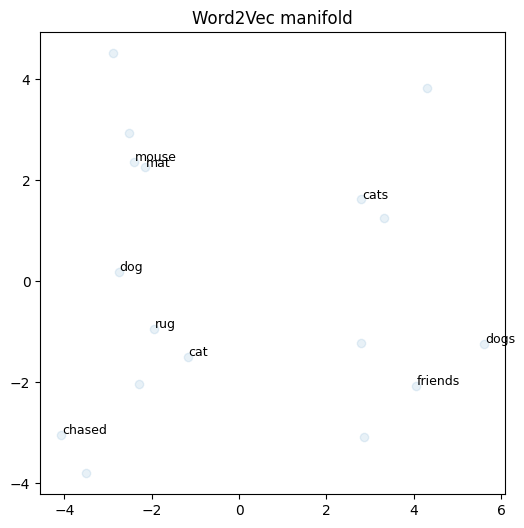

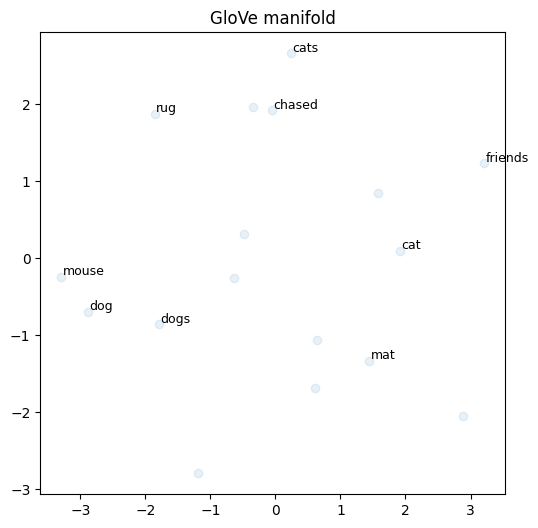

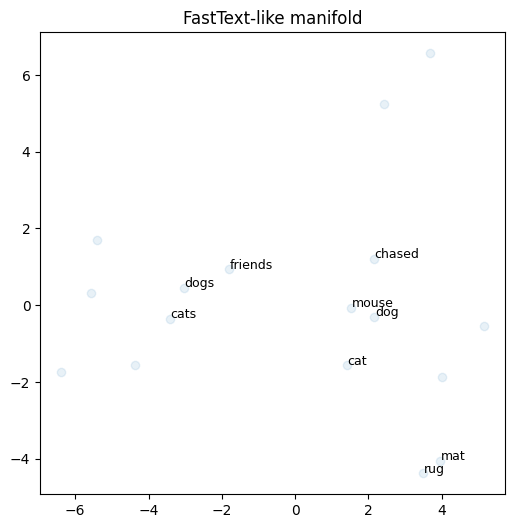

In [45]:
X2_w2v = project_pca(w2v_embeddings)
plot_embedding_2d(X2_w2v, vocab, "Word2Vec manifold", highlight_words)

X2_glove = project_pca(glove_embeddings)
plot_embedding_2d(X2_glove, vocab, "GloVe manifold", highlight_words)

X2_fast = project_pca(fasttext_embeddings)
plot_embedding_2d(X2_fast, vocab, "FastText-like manifold", highlight_words)


# Part 2 – Seq2Seq using Learned Embeddings

We now build a simple **encoder–decoder (seq2seq)** model that takes a sentence and outputs the same sentence **with word order reversed**. The goal is to demonstrate how fixed or pretrained embeddings (e.g. from Word2Vec, GloVe, or FastText) can be reused as input representations for downstream sequence models.

The **encoder** reads the input sentence and compresses it into a single hidden state — a vector that represents the entire sequence. The **decoder** then uses this hidden state to generate the reversed sentence, one token at a time. During training, we use *teacher forcing*, feeding the correct previous token to the decoder at each step to stabilize learning.

You will implement this by defining three modules:  
1. **Encoder** – embedding + GRU that outputs the final hidden state.  
2. **Decoder** – embedding + GRU + linear layer that predicts the next token.  
3. **Seq2Seq** – a wrapper that connects them and defines the forward pass.  

Finally, we train the model using **CrossEntropyLoss** on (input, reversed target) pairs and compare results when initializing the encoder with different embeddings. Observe how pretrained representations affect learning speed and the quality of generated reversed sentences.


In [46]:
PAD_TOKEN = "<pad>"
BOS_TOKEN = "<bos>"
EOS_TOKEN = "<eos>"



for tok in [PAD_TOKEN, BOS_TOKEN, EOS_TOKEN]:
    if tok not in stoi:
        stoi[tok] = len(stoi)
        vocab.append(tok)

itos = {i: w for w, i in stoi.items()}
vocab_size = len(vocab)
pad_idx = stoi[PAD_TOKEN]
bos_idx = stoi[BOS_TOKEN]
eos_idx = stoi[EOS_TOKEN]

print("Extended vocab size (with special tokens):", vocab_size)


Extended vocab size (with special tokens): 20


In [47]:
def encode_sentence(sentence, add_bos_eos=True, reverse_target=False):
    words = sentence.split()
    inp = [stoi[w] for w in words]
    if add_bos_eos:
        inp = [bos_idx] + inp + [eos_idx]

    if reverse_target:
        tgt_words = list(reversed(words))
        tgt = [stoi[w] for w in tgt_words]
        tgt = [bos_idx] + tgt + [eos_idx]
    else:
        tgt = inp[:]

    return inp, tgt

pairs_seq2seq = []
max_len_inp = 0
max_len_tgt = 0

for sent in corpus:
    inp, tgt = encode_sentence(sent, add_bos_eos=True, reverse_target=True)
    pairs_seq2seq.append((inp, tgt))
    max_len_inp = max(max_len_inp, len(inp))
    max_len_tgt = max(max_len_tgt, len(tgt))

print("Example seq2seq pair:", pairs_seq2seq[0])
print("Max lens:", max_len_inp, max_len_tgt)


Example seq2seq pair: ([18, 16, 4, 15, 13, 16, 11, 19], [18, 11, 16, 13, 15, 4, 16, 19])
Max lens: 8 8


In [48]:
def pad_sequence(seq, max_len, pad_value):
    return seq + [pad_value] * (max_len - len(seq))

inputs_padded = []
targets_padded = []

for inp, tgt in pairs_seq2seq:
    inputs_padded.append(pad_sequence(inp, max_len_inp, pad_idx))
    targets_padded.append(pad_sequence(tgt, max_len_tgt, pad_idx))

inputs_tensor = torch.tensor(inputs_padded, dtype=torch.long)
targets_tensor = torch.tensor(targets_padded, dtype=torch.long)

dataset = TensorDataset(inputs_tensor, targets_tensor)
loader = DataLoader(dataset, batch_size=2, shuffle=True)

inputs_tensor.shape, targets_tensor.shape


(torch.Size([8, 8]), torch.Size([8, 8]))

## 8. Seq2Seq model (Encoder–Decoder with GRU)

We implement:

- **Encoder**: Embedding (initialized from Word2Vec) + GRU, returns final hidden state.
- **Decoder**: Embedding + GRU + Linear to vocab logits, trained with **teacher forcing**.


In [49]:

emb_dim = w2v_embeddings.shape[1]
hidden_dim = 64

class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx, pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        if pretrained_emb is not None:
            with torch.no_grad():
                # TODO: copy pretrained embeddings (for words that exist in that matrix)
                self.embedding.weight[:pretrained_emb.size(0)].copy_(pretrained_emb)

                ...
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        # src: (B, T_in)
        embedded = self.embedding(src)       # TODO: embed src
        outputs, hidden = self.gru(embedded) # TODO: run through GRU
        return hidden         # (1, B, H)


In [50]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt, hidden):
        """
        tgt: (B, T_out)  -- teacher-forcing input
        hidden: (1, B, H)
        """
        emb = self.embedding(tgt)           # TODO: embed tgt
        outputs, hidden = self.gru(emb, hidden)  # TODO: GRU
        logits = self.out(outputs)         # TODO: project to vocab
        return logits, hidden


In [51]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, bos_idx, eos_idx, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.pad_idx = pad_idx

    def forward(self, src, tgt):
        """
        src: (B, T_in)
        tgt: (B, T_out) full target sequence (incl. BOS/EOS)

        During training we use teacher forcing:
          - decoder input: tgt[:, :-1]
          - predict: tgt[:, 1:]
        """
        enc_hidden = self.encoder(src)              # TODO: encode src
        dec_input = tgt[:, :-1]        # (B, T_out-1)
        logits, _ = self.decoder(dec_input, enc_hidden)                # TODO: decode
        return logits                  # (B, T_out-1, V)


## Training !

In [52]:
encoder = Encoder(vocab_size, emb_dim, hidden_dim, pad_idx, pretrained_emb=w2v_embeddings).to(device)
decoder = Decoder(vocab_size, emb_dim, hidden_dim, pad_idx).to(device)
model = Seq2Seq(encoder, decoder, bos_idx, eos_idx, pad_idx).to(device)

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

num_epochs = 200

for epoch in range(1, num_epochs + 1):
    model.train()
    total_loss = 0.0
    total_tokens = 0

    for src_batch, tgt_batch in loader:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)

        optimizer.zero_grad()
        logits = model(src_batch, tgt_batch)                 # TODO: forward: (B, T_out-1, V)
        tgt_out = tgt_batch[:, 1:]   # (B, T_out-1)

        print("logits shape:", logits.shape)
        print("tgt_out shape:", tgt_out.shape)
        print("vocab_size:", vocab_size)

        loss = criterion(
            logits.reshape(-1, vocab_size),
            tgt_out.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        mask = (tgt_out != pad_idx)
        total_loss += loss.item() * mask.sum().item()
        total_tokens += mask.sum().item()

    if epoch % 50 == 0:
        print(f"Epoch {epoch}/{num_epochs} - avg loss/token: {total_loss / max(total_tokens,1):.4f}")


logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: torch.Size([2, 7])
vocab_size: 20
logits shape: torch.Size([2, 7, 20])
tgt_out shape: to

## Decode

Compare the different pretrained embeddings. What happens if you test a different example from the "corpus" variable?


In [53]:
def decode_sentence(model, sentence, max_len=20):
    model.eval()
    inp, _ = encode_sentence(sentence, add_bos_eos=True, reverse_target=True)
    src = torch.tensor([pad_sequence(inp, max_len_inp, pad_idx)], dtype=torch.long).to(device)

    with torch.no_grad():
        enc_hidden = model.encoder(src)  # (1, 1, H)
        dec_input = torch.tensor([[bos_idx]], dtype=torch.long).to(device)
        hidden = enc_hidden
        generated = []

        for _ in range(max_len):
            logits, hidden = model.decoder(dec_input, hidden)
            next_token = logits.argmax(dim=-1)[:, -1]
            token_id = next_token.item()
            if token_id == eos_idx:
                break
            generated.append(token_id)
            dec_input = next_token.unsqueeze(1)

    return " ".join(itos[i] for i in generated)

for s in corpus: # can add here more examples corpus + ["cat chases dog"]
    out = decode_sentence(model, s, max_len=max_len_tgt)
    print("IN: ", s)
    print("OUT:", out)
    print("------")


IN:  the cat sat on the mat
OUT: mat the on sat cat the
------
IN:  the dog lay on the rug
OUT: rug the on lay dog the
------
IN:  dogs and cats are friends
OUT: friends are cats and dogs
------
IN:  the cat chased the mouse
OUT: mouse the chased cat the
------
IN:  the dog chased the cat
OUT: cat the chased dog the
------
IN:  cats and dogs can be friends
OUT: friends be can dogs and cats
------
IN:  dogs are friends
OUT: friends are dogs
------
IN:  the dog sat on the mat
OUT: mat the on sat dog the
------


# Part 3 – Big Seq2Seq Encoder–Decoder

In this part, we scale up the previous experiment by training the seq2seq model on a **larger real-world corpus** (e.g. AG_NEWS). The goal is to observe how the same encoder–decoder architecture behaves when trained on thousands of sentences, and how initialization with different embeddings — **Word2Vec**, **GloVe**, or **FastText** — influences convergence and generalization.

The setup remains the same: the **encoder** encodes an input sentence into a hidden vector, and the **decoder** reconstructs the sequence in reverse order, predicting one token at a time. This time, however, we use longer sentences, mini-batching, and a clear train/validation split to monitor overfitting and learning progress.

By reusing pretrained embedding matrices, we transfer prior word-level knowledge into the model, allowing it to start from a more structured representation space. You will train three versions of the model — one per embedding type — and compare their learning curves and qualitative outputs.

At the end, inspect a few decoded examples to evaluate whether the models truly capture word order and sequence structure, and discuss which embedding type provides faster convergence or more accurate reconstructions.


In [54]:
!pip install -q gensim datasets

In [55]:
import math
from collections import Counter
import random

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from datasets import load_dataset
import gensim
from gensim.models import Word2Vec, FastText
import gensim.downloader as api  # for pretrained GloVe

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

torch.manual_seed(0)
random.seed(0)


Using device: cpu


# Seq2Seq with Word2Vec, GloVe, and FastText on a Bigger Corpus

We will:

1. Load a larger text corpus (AG_NEWS via hugginface `datasets`).
2. Train **Word2Vec** and **FastText** with `gensim`.
3. Load pretrained **GloVe** with `gensim.downloader`.
4. Build a **reverse-sentence seq2seq** task:
   - Input: sentence
   - Target: sentence with **reversed token order**
5. Train and validate 3 encoder–decoder models:
   - Encoder initialized with Word2Vec / GloVe / FastText embeddings.
   - Compare their behavior.


In [56]:
MAX_SENTENCES = 20000     # increase if you want more data
MAX_TOKENS_PER_SENT = 20  # truncate long sentences for seq2seq
MIN_FREQ = 5              # min frequency to keep a token in vocabulary

def simple_tokenize(text):
    # Very naive tokenization, but enough for this lab.
    return text.lower().split()

# Load AG_NEWS from HuggingFace datasets
ag_news = load_dataset("ag_news", split="train")  # ~120k examples

sentences = []
for example in ag_news:
    text = example["text"]
    tokens = simple_tokenize(text)
    if len(tokens) == 0:
        continue
    tokens = tokens[:MAX_TOKENS_PER_SENT]  # truncate for seq2seq
    sentences.append(tokens)
    if len(sentences) >= MAX_SENTENCES:
        break

print("Num sentences:", len(sentences))
print("Example:", sentences[0])


Num sentences: 20000
Example: ['wall', 'st.', 'bears', 'claw', 'back', 'into', 'the', 'black', '(reuters)', 'reuters', '-', 'short-sellers,', 'wall', "street's", 'dwindling\\band', 'of', 'ultra-cynics,', 'are', 'seeing', 'green']


In [57]:
PAD = "<pad>"
BOS = "<bos>"
EOS = "<eos>"
UNK = "<unk>"

# TODO: 1) Count token frequencies over the corpus
counter = Counter(t for sent in sentences for t in sent)


# TODO: 2) Keep only tokens with frequency >= MIN_FREQ
vocab_tokens = [tok for tok, c in counter.items() if c >= MIN_FREQ]

# Special tokens first
itos = [PAD, BOS, EOS, UNK] + sorted(vocab_tokens)
stoi = {tok: i for i, tok in enumerate(itos)}
vocab_size = len(itos)

pad_idx = stoi[PAD]
bos_idx = stoi[BOS]
eos_idx = stoi[EOS]
unk_idx = stoi[UNK]

print("Vocab size:", vocab_size)
print("First 20 tokens:", itos[:20])


Vocab size: 8601
First 20 tokens: ['<pad>', '<bos>', '<eos>', '<unk>', '"madden', '"the', '#146;s', '#151;', '#36;47', '#39;', '#39;a', '#39;d', '#39;hare', '#39;i', '#39;ite', '#39;ll', '#39;m', '#39;madden', '#39;marathon', '#39;re']


In [58]:
EMB_DIM = 100

# TODO (optional): play with hyperparameters (window, min_count, sg, epochs)
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=EMB_DIM,
    window=5,
    min_count=MIN_FREQ,
    workers=4,
    sg=1,           # 1 = skip-gram, 0 = CBOW
    epochs=5
)
print("Trained Word2Vec with vocab size (gensim):", len(w2v_model.wv))

ft_model = FastText(
    sentences=sentences,
    vector_size=EMB_DIM,
    window=5,
    min_count=MIN_FREQ,
    workers=4,
    sg=1,
    epochs=5
)
print("Trained FastText with vocab size (gensim):", len(ft_model.wv))


Trained Word2Vec with vocab size (gensim): 8597
Trained FastText with vocab size (gensim): 8597


In [59]:
# This will download if needed; cached afterwards.
# TODO (optional): try different models, e.g. "glove-wiki-gigaword-50"
glove = api.load("glove-wiki-gigaword-100")  # 100-dim GloVe
print("GloVe vocab size:", len(glove))


GloVe vocab size: 400000


In [60]:
def build_embedding_matrix_from_gensim(model, stoi, emb_dim):
    """
    For each token in our vocab, retrieve its vector from a gensim model.
    If it's missing, keep a small random vector.
    """
    mat = torch.randn(len(stoi), emb_dim) * 0.01
    for tok, idx in stoi.items():
        # TODO: if tok is in model.wv, copy its vector into mat[idx]


        if tok in model.wv:
            mat[idx] = torch.tensor(model.wv[tok], dtype=torch.float)

            
        ...
    return mat

def build_embedding_matrix_from_glove(glove_model, stoi, emb_dim):
    """
    Same idea, but using a gensim GloVe embedding.
    """
    mat = torch.randn(len(stoi), emb_dim) * 0.01
    for tok, idx in stoi.items():
        # TODO: if tok is in glove_model, copy its vector into mat[idx]
        if tok in glove_model:
            mat[idx] = torch.tensor(glove_model[tok], dtype=torch.float)
    return mat

w2v_embeddings = build_embedding_matrix_from_gensim(w2v_model, stoi, EMB_DIM)
ft_embeddings  = build_embedding_matrix_from_gensim(ft_model,  stoi, EMB_DIM)
glove_embeddings = build_embedding_matrix_from_glove(glove,     stoi, EMB_DIM)

print("W2V emb matrix:", w2v_embeddings.shape)
print("FastText emb matrix:", ft_embeddings.shape)
print("GloVe emb matrix:", glove_embeddings.shape)


W2V emb matrix: torch.Size([8601, 100])
FastText emb matrix: torch.Size([8601, 100])
GloVe emb matrix: torch.Size([8601, 100])


In [61]:
def encode_tokens(tokens, stoi, max_len):
    """
    Map a list of tokens to IDs using stoi.
    Unknown tokens go to UNK; truncate to max_len.
    """
    ids = [stoi.get(t, unk_idx) for t in tokens]
    ids = ids[:max_len]
    return ids

def make_seq2seq_example(tokens, max_len_tokens):
    """
    Input:  BOS + tokens + EOS
    Target: BOS + reversed(tokens) + EOS
    """
    # TODO: 1) Encode tokens and reversed tokens with encode_tokens(...)
    # TODO: 2) Add BOS/EOS around them


    inp_ids = [bos_idx] + encode_tokens(tokens, stoi, max_len_tokens - 2) + [eos_idx]
    tgt_ids = [bos_idx] + encode_tokens(list(reversed(tokens)), stoi, max_len_tokens - 2) + [eos_idx]    


    return inp_ids, tgt_ids
max_len_tokens = MAX_TOKENS_PER_SENT

examples = [make_seq2seq_example(sent, max_len_tokens) for sent in sentences]

# Train/val split
train_ratio = 0.9
split_idx = int(len(examples) * train_ratio)
train_data = examples[:split_idx]
val_data   = examples[split_idx:]

len(train_data), len(val_data)


(18000, 2000)

In [62]:
def pad_to_max_len(seq, max_len, pad_value):
    return seq + [pad_value] * (max_len - len(seq))

# Compute max lengths across corpus
max_len_inp = max(len(inp) for inp, _ in examples)
max_len_tgt = max(len(tgt) for _, tgt in examples)
print("Max input len:", max_len_inp, "Max target len:", max_len_tgt)

class ReverseDataset(Dataset):
    def __init__(self, pairs, max_len_inp, max_len_tgt, pad_idx):
        self.pairs = pairs
        self.max_len_inp = max_len_inp
        self.max_len_tgt = max_len_tgt
        self.pad_idx = pad_idx

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        inp, tgt = self.pairs[idx]
        inp_p = pad_to_max_len(inp, self.max_len_inp, self.pad_idx)
        tgt_p = pad_to_max_len(tgt, self.max_len_tgt, self.pad_idx)
        return torch.tensor(inp_p, dtype=torch.long), torch.tensor(tgt_p, dtype=torch.long)

train_dataset = ReverseDataset(train_data, max_len_inp, max_len_tgt, pad_idx)
val_dataset   = ReverseDataset(val_data,   max_len_inp, max_len_tgt, pad_idx)

BATCH_SIZE = 64

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE)

len(train_loader), len(val_loader)


Max input len: 20 Max target len: 20


(282, 32)

In [63]:
class Encoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx, pretrained_emb=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        if pretrained_emb is not None:
            with torch.no_grad():
                # TODO: copy pretrained_emb into self.embedding.weight
                self.embedding.weight[:pretrained_emb.size(0)].copy_(pretrained_emb)
                self.embedding.weight.requires_grad = False
                
                ...
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)

    def forward(self, src):
        """
        src: (B, T_in)
        returns: hidden state (1, B, H)
        """
        # TODO: embed src and pass through GRU
        emb = self.embedding(src)
        outputs, hidden = self.gru(emb)
        return hidden


class Decoder(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, pad_idx):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(emb_dim, hidden_dim, batch_first=True)
        self.out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, tgt, hidden):
        """
        tgt: (B, T_out)
        hidden: (1, B, H)
        """
        # TODO: embed tgt, run GRU, project to vocabulary logits
        emb = self.embedding(tgt)
        outputs, hidden = self.gru(emb, hidden)
        logits = self.out(outputs)
        return logits, hidden


class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder, bos_idx, eos_idx, pad_idx):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.bos_idx = bos_idx
        self.eos_idx = eos_idx
        self.pad_idx = pad_idx

    def forward(self, src, tgt):
        """
        src: (B, T_in)
        tgt: (B, T_out) including BOS/EOS

        We will:

        - encode src to get enc_hidden
        - feed tgt[:, :-1] into the decoder
        - predict tgt[:, 1:]
        """
        enc_hidden = self.encoder(src)            # TODO: call encoder
        dec_input = tgt[:, :-1]
        logits, _ = self.decoder(dec_input, enc_hidden)             # TODO: call decoder
        return logits               # (B, T_out-1, V)


In [66]:
def train_seq2seq_with_embeddings(emb_matrix, num_epochs=5, hidden_dim=256, label=""):
    encoder = Encoder(vocab_size, EMB_DIM, hidden_dim, pad_idx, pretrained_emb=emb_matrix).to(device)
    decoder = Decoder(vocab_size, EMB_DIM, hidden_dim, pad_idx).to(device)
    model = Seq2Seq(encoder, decoder, bos_idx, eos_idx, pad_idx).to(device)

    criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    def run_epoch(loader, train=True):
        if train:
            model.train()
        else:
            model.eval()
        total_loss = 0.0
        total_tokens = 0

        for src_batch, tgt_batch in loader:
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)

            if train:
                optimizer.zero_grad()

            logits = model(src_batch, tgt_batch)     # (B, T_out-1, V)
            tgt_out = tgt_batch[:, 1:]               # (B, T_out-1)

            # TODO: compute loss over non-PAD tokens using criterion
            loss = criterion(logits.reshape(-1, vocab_size), tgt_out.reshape(-1))




            if train:
                # TODO: backprop + optimizer step
                loss.backward()
                optimizer.step()

            mask = (tgt_out != pad_idx)
            total_loss += loss.item() * mask.sum().item()
            total_tokens += mask.sum().item()
        return total_loss / max(total_tokens, 1)

    for epoch in range(1, num_epochs + 1):
        train_loss = run_epoch(train_loader, train=True)
        val_loss   = run_epoch(val_loader,   train=False)
        print(f"[{label}] Epoch {epoch}/{num_epochs} - train loss/token: {train_loss:.4f} - val: {val_loss:.4f}")

    return model


In [67]:
EPOCHS = 10 # increase for better results

print("Training with Word2Vec embeddings")
model_w2v = train_seq2seq_with_embeddings(w2v_embeddings, num_epochs=EPOCHS, label="W2V")

print("\nTraining with GloVe embeddings")
model_glove = train_seq2seq_with_embeddings(glove_embeddings, num_epochs=EPOCHS, label="GloVe")

print("\nTraining with FastText embeddings")
model_ft = train_seq2seq_with_embeddings(ft_embeddings, num_epochs=EPOCHS, label="FastText")


Training with Word2Vec embeddings
[W2V] Epoch 1/10 - train loss/token: 6.4301 - val: 6.1165
[W2V] Epoch 2/10 - train loss/token: 5.5927 - val: 5.6801


KeyboardInterrupt: 

In [ ]:
def decode_single(model, tokens, max_len=None):
    model.eval()
    if max_len is None:
        max_len = max_len_tgt

    inp_ids, tgt_ids = make_seq2seq_example(tokens, max_len_tokens)
    src = pad_to_max_len(inp_ids, max_len_inp, pad_idx)
    src = torch.tensor([src], dtype=torch.long).to(device)

    with torch.no_grad():
        enc_hidden = model.encoder(src)
        dec_input = torch.tensor([[bos_idx]], dtype=torch.long).to(device)
        hidden = enc_hidden
        generated = []

        for _ in range(max_len):
            # TODO: one decoding step:
            #  - call model.decoder with dec_input, hidden
            #  - take argmax over vocabulary to get next token
            #  - stop on EOS
            logits, hidden = model.decoder(dec_input, hidden)
            next_token = logits.argmax(dim=-1)[:, -1]
            token_id = next_token.item()
            if token_id == eos_idx:
                break
            generated.append(token_id)
            dec_input = next_token.unsqueeze(1)
            
    # TODO: map generated token IDs back to strings using itos
    pred_tokens = [itos[idx] for idx in generated]
    target_tokens = list(reversed(tokens))[:max_len_tokens]
    return pred_tokens, target_tokens

def print_examples(model, name, n=5):
    print(f"=== {name} ===")
    for _ in range(n):
        tokens = random.choice(sentences)
        pred, target = decode_single(model, tokens)
        print("IN:   ", " ".join(tokens))
        print("TGT:  ", " ".join(target))
        print("PRED: ", " ".join(pred))
        print()

print_examples(model_w2v,   "Word2Vec")
print_examples(model_glove, "GloVe")
print_examples(model_ft,    "FastText")


## Questions based on Part 3

1. How do the **train/val losses** compare between:
   - Word2Vec encoder
   - GloVe encoder
   - FastText encoder?

2. Qualitatively:
   - Which model produces the best reversed sequences?
   - Are some models better at keeping all tokens vs. others?

3. If you increase `MAX_SENTENCES` and `EPOCHS`, how does performance change?
4. How would you adapt this setup to a **real translation task** instead of simple reversal?
